In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cat-sound-classification-dataset/CAT_DB/HuntingMind/car_extcoll0329.mp3
/kaggle/input/cat-sound-classification-dataset/CAT_DB/HuntingMind/car_extcoll0328.mp3
/kaggle/input/cat-sound-classification-dataset/CAT_DB/HuntingMind/car_extcoll0331.mp3
/kaggle/input/cat-sound-classification-dataset/CAT_DB/HuntingMind/car_extcoll0326.mp3
/kaggle/input/cat-sound-classification-dataset/CAT_DB/HuntingMind/Cat_trilling0111.mp3
/kaggle/input/cat-sound-classification-dataset/CAT_DB/HuntingMind/Cat_trilling0113.mp3
/kaggle/input/cat-sound-classification-dataset/CAT_DB/HuntingMind/car_extcoll0327.mp3
/kaggle/input/cat-sound-classification-dataset/CAT_DB/HuntingMind/car_extcoll0330.mp3
/kaggle/input/cat-sound-classification-dataset/CAT_DB/HuntingMind/Cat_trilling0112.mp3
/kaggle/input/cat-sound-classification-dataset/CAT_DB/HuntingMind/car_extcoll0332.mp3
/kaggle/input/cat-sound-classification-dataset/CAT_DB/Resting/cat_coll0110.mp3
/kaggle/input/cat-sound-classification-dataset/CAT_DB/Rest

In [43]:
import os
import numpy as np
import librosa
import random
import tensorflow as tf
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split

In [44]:
DATASET_PATH = "/kaggle/input/cat-sound-classification-dataset/CAT_DB"  # Folder with subfolders for each class
SR = 16000           # Sample rate
N_MELS = 64
N_FFT = 1024
HOP_LENGTH = 512
MAX_FRAMES = 96      # number of time frames per sample
AUG_PER_FILE = 5     # number of augmentations per file

**Augmentation**

In [45]:
def safe_augment(y, sr):
    augmented = []

    # 1. Original
    augmented.append(y)

    # 2. Time-stretch
    try:
        y_ts = librosa.effects.time_stretch(y, rate=random.uniform(0.8, 1.25))
        augmented.append(y_ts)
    except:
        augmented.append(y)

    # 3. Pitch shift
    try:
        y_ps = librosa.effects.pitch_shift(y, sr=sr, n_steps=random.randint(-4, 4))
        augmented.append(y_ps)
    except:
        augmented.append(y)

    # 4. Add noise
    noise = np.random.randn(len(y)) * 0.005
    augmented.append(y + noise)

    # 5. Change volume
    y_vol = y * random.uniform(0.7, 1.3)
    augmented.append(y_vol)

    return augmented[:AUG_PER_FILE]

In [46]:
def extract_mel_2d(y, sr=SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH, max_frames=MAX_FRAMES):
    # Pad short audio
    if len(y) < sr:
        y = np.pad(y, (0, sr - len(y)), 'constant')

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = mel_db.T

    # Pad/truncate to fixed number of frames
    if mel_db.shape[0] < max_frames:
        pad_width = max_frames - mel_db.shape[0]
        mel_db = np.pad(mel_db, ((0, pad_width), (0, 0)), mode='constant')
    else:
        mel_db = mel_db[:max_frames, :]

    # Add channel dimension for CNN
    return mel_db[..., np.newaxis]

In [47]:
X = []
y_labels = []

classes = os.listdir(DATASET_PATH)
for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    for file in os.listdir(cls_path):
        if file.endswith(".mp3"):
            file_path = os.path.join(cls_path, file)
            y, sr = librosa.load(file_path, sr=SR)
            augmented_audios = safe_augment(y, sr)
            for aug_audio in augmented_audios:
                X.append(extract_mel_2d(aug_audio, sr))
                y_labels.append(cls)

X = np.array(X, dtype=np.float32)
print("Dataset shape:", X.shape)

Dataset shape: (500, 96, 64, 1)


In [48]:
lb = LabelBinarizer()
y_encoded = lb.fit_transform(y_labels)
print("Labels shape:", y_encoded.shape)


Labels shape: (500, 10)


In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [50]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(MAX_FRAMES, N_MELS, 1)),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),
    
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(len(classes), activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 94, 62, 32)        320       
                                                                 
 batch_normalization_2 (Batc  (None, 94, 62, 32)       128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 47, 31, 32)       0         
 2D)                                                             
                                                                 
 conv2d_3 (Conv2D)           (None, 45, 29, 64)        18496     
                                                                 
 batch_normalization_3 (Batc  (None, 45, 29, 64)       256       
 hNormalization)                                                 
                                                      

In [51]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16
)

Epoch 1/50
25/25 [==============================] - 5s 121ms/step - loss: 2.2751 - accuracy: 0.3925 - val_loss: 3.6814 - val_accuracy: 0.2300
Epoch 2/50
25/25 [==============================] - 3s 109ms/step - loss: 0.7853 - accuracy: 0.7475 - val_loss: 3.4985 - val_accuracy: 0.1000
Epoch 3/50
25/25 [==============================] - 3s 107ms/step - loss: 0.4001 - accuracy: 0.8675 - val_loss: 2.1225 - val_accuracy: 0.3100
Epoch 4/50
25/25 [==============================] - 3s 108ms/step - loss: 0.3487 - accuracy: 0.8925 - val_loss: 1.3295 - val_accuracy: 0.5400
Epoch 5/50
25/25 [==============================] - 3s 109ms/step - loss: 0.1876 - accuracy: 0.9450 - val_loss: 1.0824 - val_accuracy: 0.6400
Epoch 6/50
25/25 [==============================] - 3s 109ms/step - loss: 0.1968 - accuracy: 0.9575 - val_loss: 0.6983 - val_accuracy: 0.8000
Epoch 7/50
25/25 [==============================] - 3s 109ms/step - loss: 0.1602 - accuracy: 0.9550 - val_loss: 0.4598 - val_accuracy: 0.8600
Epoch 

In [52]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 96.00%
Test Loss: 0.0912


In [53]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

4/4 [==============================] - 0s 33ms/step


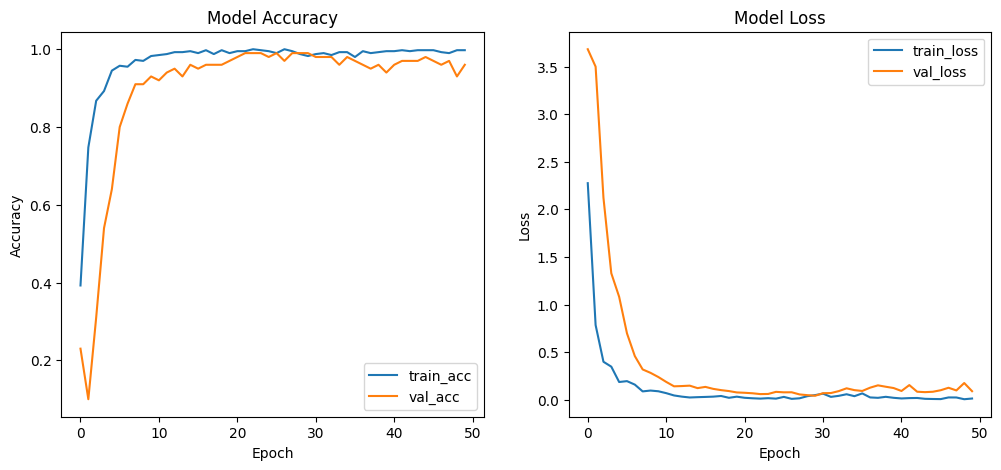

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

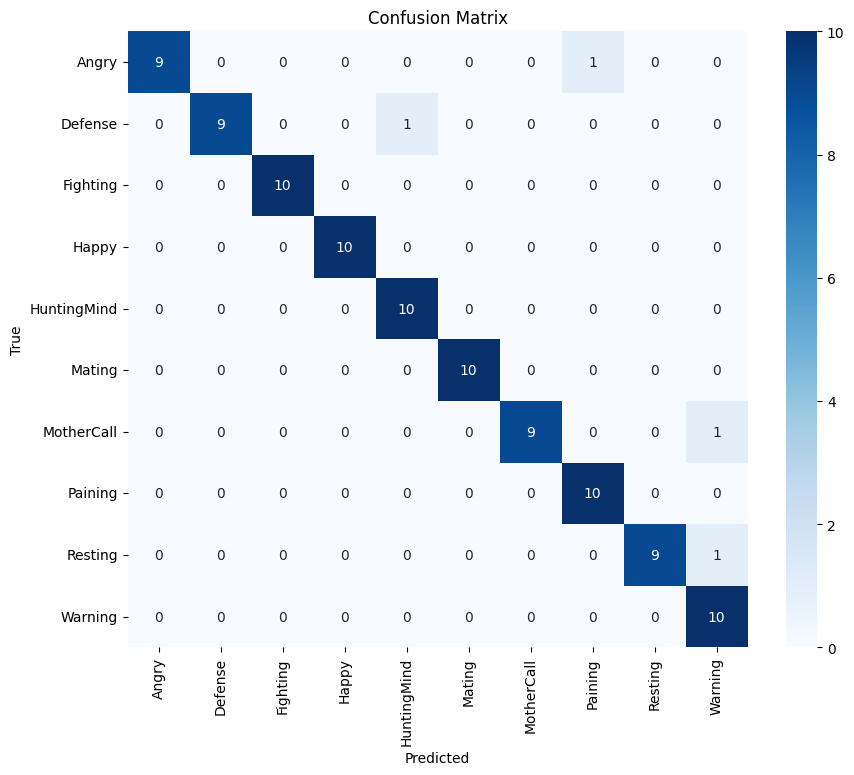

In [55]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=lb.classes_, yticklabels=lb.classes_, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [56]:
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=lb.classes_))

Classification Report:
              precision    recall  f1-score   support

       Angry       1.00      0.90      0.95        10
     Defense       1.00      0.90      0.95        10
    Fighting       1.00      1.00      1.00        10
       Happy       1.00      1.00      1.00        10
 HuntingMind       0.91      1.00      0.95        10
      Mating       1.00      1.00      1.00        10
  MotherCall       1.00      0.90      0.95        10
     Paining       0.91      1.00      0.95        10
     Resting       1.00      0.90      0.95        10
     Warning       0.83      1.00      0.91        10

    accuracy                           0.96       100
   macro avg       0.97      0.96      0.96       100
weighted avg       0.97      0.96      0.96       100



In [59]:
# Save model in HDF5 format
model.save("cat_sound_cnn_model.h5")